In [2]:
import harpy as hp
import spatialdata_plot

_ = spatialdata_plot

#### Create SpatialData object

In [17]:
import tempfile
from pathlib import Path

from spatialdata import read_zarr

tmp = tempfile.TemporaryDirectory(prefix="vectrapolaris_")
output_dir = Path(tmp.name)

path = None

sdata = hp.datasets.vectra_example(
    path=path,
)
sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

sdata

2026-05-24 20:20:47.425 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'image'


SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/vectrapolaris_vnbldvv0/sdata.zarr
└── Images
      └── 'image': DataTree[cyx] (8, 1400, 1868), (8, 700, 934), (8, 350, 467), (8, 175, 233)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images)
    ▸ 'global_micron', with elements:
        image (Images)

In [18]:
sdata["image"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 8, y: 1400, x: 1868)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 11kB 0.5 1.5 2.5 3.5 ... 1.398e+03 1.398e+03 1.4e+03
│         * x        (x) float64 15kB 0.5 1.5 2.5 3.5 ... 1.866e+03 1.866e+03 1.868e+03
│       Data variables:
│           image    (c, y, x) float32 84MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 8, y: 700, x: 934)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 6kB 1.0 3.0 5.0 7.0 ... 1.395e+03 1.397e+03 1.399e+03
│         * x        (x) float64 7kB 1.0 3.0 5.0 7.0 ... 1.863e+03 1.865e+03 1.867e+03
│       Data variables:
│           image    (c, y, x) float32 21MB dask.array<chunksize=(1, 700, 934), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 8, y: 350, x: 467)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 3kB 2.0 6.0 10.0 14.0 ... 1.39e+03 1.394e+03 1.398e+03
│         * x        (x) float64 4kB 2.0 6.0 10.0 14.0 ... 1.858e+03 1.862e+03 1.866e+03
│       Data variables:
│           image    (c, y, x) float32 5MB dask.array<chunksize=(1, 350, 467), meta=np.ndarray>
└── Group: /scale3
        Dimensions:  (c: 8, y: 175, x: 233)
        Coordinates:
          * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
          * y        (y) float64 1kB 4.0 12.0 20.0 28.0 ... 1.38e+03 1.388e+03 1.396e+03
          * x        (x) float64 2kB 4.009 12.03 20.04 ... 1.848e+03 1.856e+03 1.864e+03
        Data variables:
            image    (c, y, x) float32 1MB dask.array<chunksize=(1, 175, 233), meta=np.ndarray>

In [ ]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

In [ ]:
# good practice to rechunk on disk
from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=hp.im.get_dataarray(sdata, element_name="image").data.rechunk((8, 500, 500)),
    output_image_name="image",
    scale_factors=[2, 2, 2],
    c_coords=hp.im.get_dataarray(sdata, element_name="image").c.data,
    transformations=get_transformation(sdata["image"], get_all=True),
    overwrite=True,
)

2026-05-24 20:21:52.331 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'image'
2026-05-24 20:21:52.633 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image' already exists. Overwriting...


In [20]:
sdata.is_backed()

True

In [21]:
channels = hp.im.get_dataarray(sdata, element_name="image").c.data
channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

In [24]:
channels = hp.im.get_dataarray(sdata, element_name="image").c.data
channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

#### Visualize

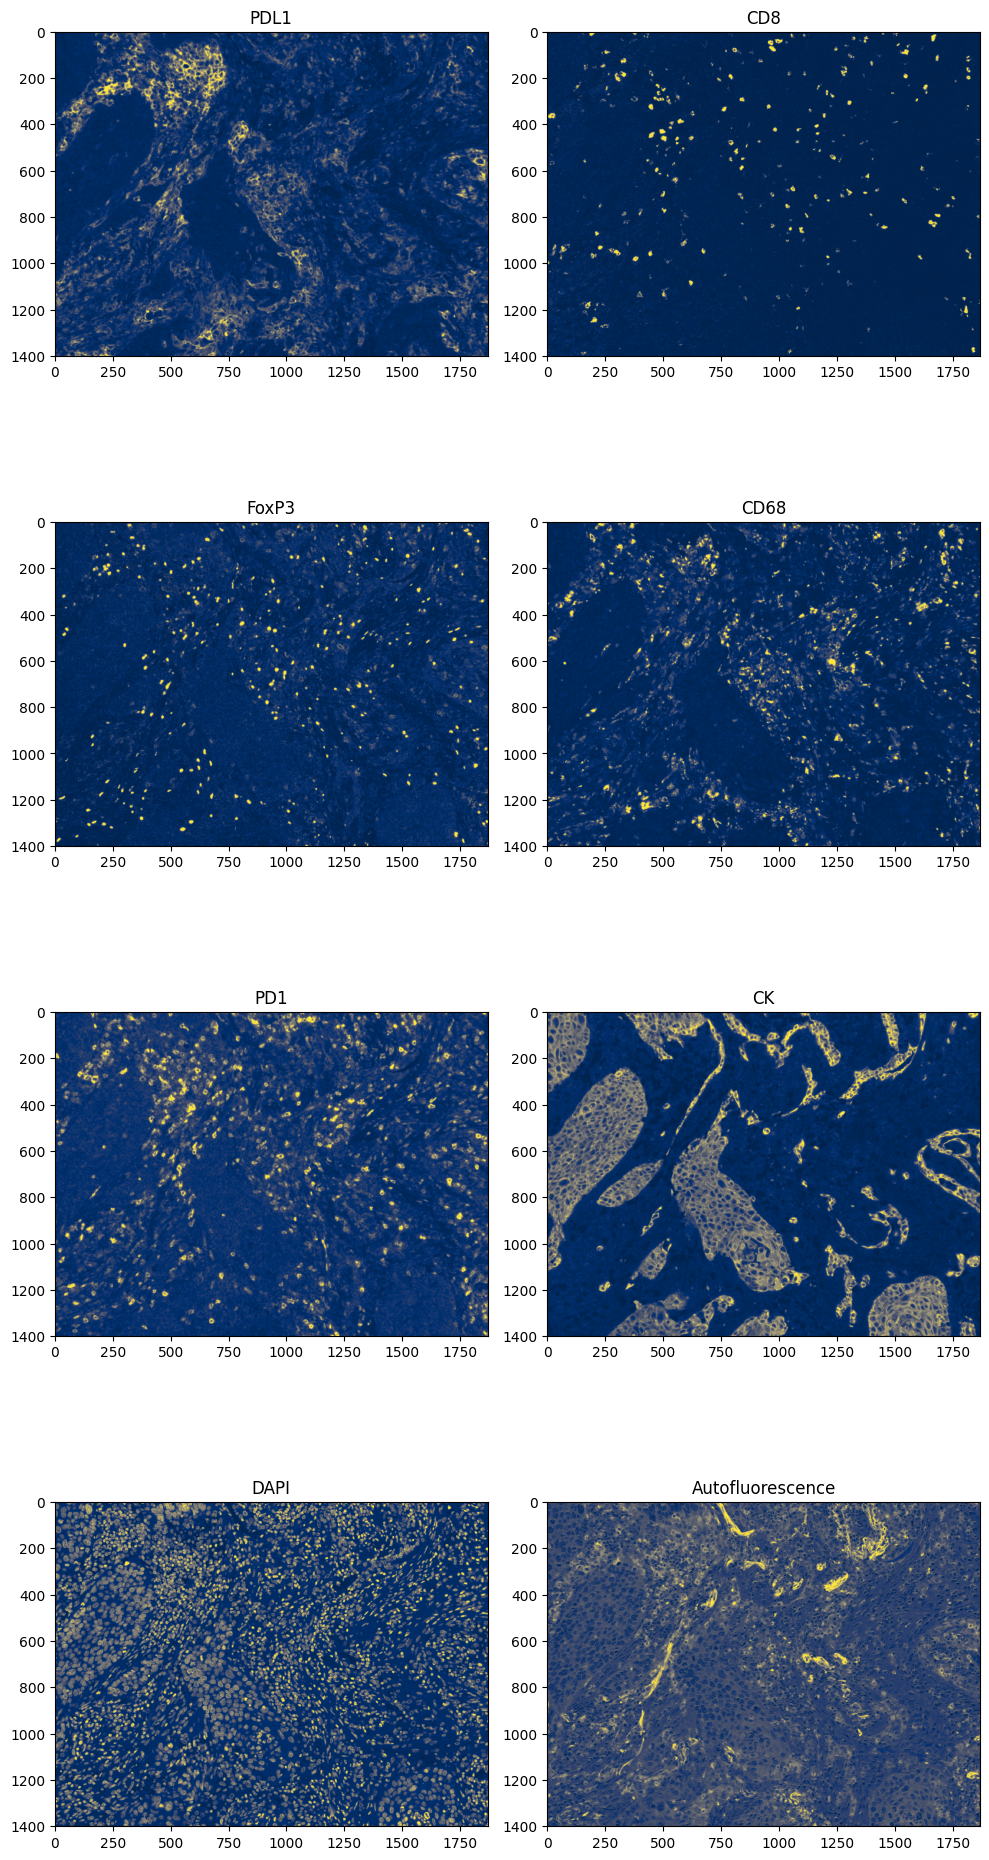

In [ ]:
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
_image_name = "image"
to_coordinate_system = "global"

se = hp.im.get_dataarray(sdata, element_name=_image_name)
channels = se.c.data

for _ax, _channel in zip(axes.flatten(), channels, strict=True):
    # normalization parameters for visualization (underlying image not changed)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {"cmap": "cividis", "norm": norm}
    show_kwargs = {"title": _channel, "colorbar": False}
    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )
    # frameless figure
    # _ax.axis("off")

plt.tight_layout()
plt.show()

Plot histogram

<b>Excercise</b>:

- Plot the histogram of channel 0 of `image`.
- Go to the [documentation](https://harpy.readthedocs.io/en/latest/generated/harpy.pl.histogram.html) of `harpy`.

<details>
<summary>Click to reveal the solution</summary>

```python

import matplotlib.ticker as ticker

ax=hp.pl.histogram(
    sdata,
    img_layer="image",
    channel=0,
    bins=100,
    fig_kwargs={ "figsize":(3,3,) },
    )

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
```

#### Segment using InstanSeg.

Download an `instanseg` model first.

In [ ]:
import os
import zipfile

import requests


def download_and_unzip(url, extract_to):
    try:
        os.makedirs(extract_to, exist_ok=False)
    except FileExistsError:
        print("Model already downloaded.")
        return
    local_zip_path = os.path.join(extract_to, "downloaded.zip")
    print("Downloading...")
    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(local_zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print("Unzipping...")
    with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)
    os.remove(local_zip_path)
    print(f"Done! Files extracted to: {extract_to}")


url = "https://github.com/instanseg/instanseg/releases/download/instanseg_models_v0.1.0/fluorescence_nuclei_and_cells.zip"
target_path = os.path.join(OUTPUT_DIR, "fluorescence_nuclei_and_cells")
download_and_unzip(url, target_path)

In [ ]:
import os

import torch
from instanseg import InstanSeg

path_model = os.path.join(target_path, "instanseg.pt")

instanseg_fluorescence = torch.load(path_model, weights_only=False)
instanseg_fluorescence = InstanSeg(model_type=instanseg_fluorescence, device="cpu")

In [ ]:
from dask.distributed import Client, LocalCluster
from instanseg import InstanSeg

workers = 4
threads = 1

if workers is not None and threads is not None:
    cluster = LocalCluster(
        n_workers=workers,
        threads_per_worker=threads,
        memory_limit="500GB",  # prevent spilling to disk
    )

    client = Client(cluster)

print(client.dashboard_link)

In [ ]:
sdata["image"].data

We'll now segment the cells with `instanseg` implemented in Harpy. Check the [documentation](https://harpy.readthedocs.io/en/latest/generated/harpy.im.instanseg_callable.html).


In [ ]:
import harpy as hp

# takes 1m on mac m2

sdata = hp.im.segment(
    sdata,
    img_layer="image",
    output_labels_layer=["labels_nuclei_instanseg", "labels_cells_instanseg"],
    output_shapes_layer=None,
    labels_layer_align="labels_cells_instanseg",
    depth=50,
    chunks=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="all_outputs",
    device="cpu",
    instanseg_model=path_model,  # load it in every worker, because torchscript model is not serializable
    iou=True,
    trim=False,
    overwrite=True,
)

In [ ]:
sdata

In [ ]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[200, 200],
    max_coordinate=[500, 500],
    axes=("x", "y"),
    target_coordinate_system="global",
)
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_cells_instanseg", fill_alpha=0.5
).pl.show(title="cells")
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_nuclei_instanseg", fill_alpha=0.5
).pl.show(title="nuclei")  # although colors are different, labels are aligned.

Cell segmentation does not seem great if we use instanseg mode to `all_outputs`.

In [ ]:
# from napari_spatialdata import Interactive

# Interactive( sdata )

A better option is to segment cells and nuclei separately, and then align the cell and nuclei masks.

In [ ]:
# Segment the cells
sdata = hp.im.segment(
    sdata,
    img_layer="image",
    output_labels_layer=["labels_cells_instanseg"],
    output_shapes_layer=["shapes_cells_instanseg"],
    labels_layer_align=None,
    depth=50,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="cells",
    device="cpu",
    instanseg_model=path_model,  # load it in every worker, because torchscript model is not serializable
    iou=True,
    trim=False,
    overwrite=True,
)

# Segment the nuclei
sdata = hp.im.segment(
    sdata,
    img_layer="image",
    output_labels_layer=["labels_nuclei_instanseg"],
    output_shapes_layer=["shapes_nuclei_instanseg"],
    labels_layer_align=None,
    depth=50,
    chunks=(500, 500),
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="nuclei",
    device="cpu",
    instanseg_model=path_model,  # load it in every worker, because torchscript model is not serializable
    iou=True,
    trim=False,
    overwrite=True,
)

In [ ]:
sdata

In [ ]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[200, 200],
    max_coordinate=[500, 500],
    axes=("x", "y"),
    target_coordinate_system="global",
)
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_cells_instanseg", fill_alpha=0.5
).pl.show(title="cells")
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_nuclei_instanseg", fill_alpha=0.5
).pl.show(title="nuclei")  # although colors are different, labels are aligned.

Align the obtained cell and nuclei masks.

In [ ]:
sdata = hp.im.align_labels_layers(
    sdata,
    labels_layer_1="labels_nuclei_instanseg",
    labels_layer_2="labels_cells_instanseg",
    output_labels_layer="labels_nuclei_instanseg_aligned",
    output_shapes_layer="shapes_nuclei_instanseg_aligned",
    chunks=None,
    depth=50,
    overwrite=True,
)

Sanity check, to see if alignment went well.

In [ ]:
hp.pl.sanity(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_instanseg",
    points_layer=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(8, 8),
)

hp.pl.sanity(
    sdata,
    img_layer="image",
    shapes_layer="shapes_nuclei_instanseg_aligned",
    points_layer=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(8, 8),
)

hp.pl.sanity(
    sdata,
    img_layer="image",
    shapes_layer="shapes_nuclei_instanseg",
    points_layer=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(8, 8),
)

In [ ]:
# from napari_spatialdata import Interactive

# Interactive( sdata )

In [ ]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[200, 200],
    max_coordinate=[500, 500],
    axes=("x", "y"),
    target_coordinate_system="global",
)
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_cells_instanseg", fill_alpha=0.5
).pl.show(title="cells")
sdata_small.pl.render_images("image", channel=6).pl.render_labels(
    "labels_nuclei_instanseg_aligned", fill_alpha=0.5
).pl.show(title="nuclei")  # although colors are different, labels are aligned.

#### Create the AnnData table:

Allocate intensity for cells.

In [ ]:
sdata = hp.tb.allocate_intensity(
    sdata,
    labels_layer="labels_cells_instanseg",
    output_layer="table_intensities_cells",
    channels=[0, 1, 2, 3, 4, 5, 7],  # do not include DAPI (channel 6)
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    overwrite=True,
)

In [ ]:
sdata["table_intensities_cells"]

In [ ]:
sdata["table_intensities_cells"].to_df().head()

In [ ]:
sdata["table_intensities_cells"].obs.head()

Allocate intensity for nuclei

In [ ]:
sdata = hp.tb.allocate_intensity(
    sdata,
    labels_layer="labels_nuclei_instanseg_aligned",
    output_layer="table_intensities_nuclei",
    channels=[0, 1, 2, 3, 4, 5, 7],  # do not include DAPI
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    overwrite=True,
)

In [ ]:
sdata

In [ ]:
sdata["table_intensities_nuclei"].to_df().head()

In [ ]:
sdata["table_intensities_nuclei"].obs.head()

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_instanseg",
    table_layer="table_intensities_cells",
    column="var_5",
    channel=5,
    crd=[200, 500, 200, 500],
    figsize=(5, 5),
    alpha=0.4,
)

In [ ]:
# import numpy as np

# image=sdata[ "image" ].data[ 5 ].compute()
# mask=sdata[ "labels_cells_instanseg" ].data.compute() == 8059  # cell with high variance

# np.var(image[ mask ])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
ax = plt.gca()

color = "var_5"

sdata_small = sdata.query.bounding_box(
    min_coordinate=[200, 200],
    max_coordinate=[500, 500],
    axes=("x", "y"),
    target_coordinate_system="global",
)

sdata_small.pl.render_images("image", channel=5).pl.render_labels(
    "labels_cells_instanseg",
    color=color,
    method="datashader",
    fill_alpha=0.3,
    outline_alpha=0.1,
).pl.show(coordinate_systems="global", ax=ax)

### Segment using Cellpose:

In [ ]:
import matplotlib.pyplot as plt

hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer=None,
    channel=[6, 5, 1, 4],
    figsize=(5 * 4, 5 * 4),
)

In [ ]:
# takes 1m 30 on mac OS m2

arr = sdata["image"].data[6][None, ...]
sdata = hp.im.add_image_layer(
    sdata,
    arr=arr,
    output_layer="image_c6",
    overwrite=True,
)

print("Segmenting channel 6.")

sdata = hp.im.segment(
    sdata,
    img_layer="image_c6",
    model=hp.im.cellpose_callable,
    device="cpu",
    pretrained_model="nuclei",
    output_labels_layer="labels_cells_c6",
    output_shapes_layer="shapes_cells_c6",
    diameter=15,
    depth=50,
    channels=[0, 0],
    overwrite=True,
)

print("Segmenting channel 5.")

arr = sdata["image"].data[5][None, ...]
sdata = hp.im.add_image_layer(
    sdata,
    arr=arr,
    output_layer="image_c5",
    overwrite=True,
)

sdata = hp.im.segment(
    sdata,
    img_layer="image_c5",
    model=hp.im.cellpose_callable,
    device="cpu",
    pretrained_model="cyto3",
    output_labels_layer="labels_cells_c5",
    output_shapes_layer="shapes_cells_c5",
    diameter=30,
    depth=50,
    channels=[0, 0],
    overwrite=True,
)

print("Segmenting channel 1.")

arr = sdata["image"].data[1][None, ...]
sdata = hp.im.add_image_layer(
    sdata,
    arr=arr,
    output_layer="image_c1",
    overwrite=True,
)

sdata = hp.im.segment(
    sdata,
    img_layer="image_c1",
    model=hp.im.cellpose_callable,
    device="cpu",
    pretrained_model="cyto3",
    output_labels_layer="labels_cells_c1",
    output_shapes_layer="shapes_cells_c1",
    diameter=30,
    depth=50,
    channels=[0, 0],
    overwrite=True,
)

print("Segmenting channel 4.")

arr = sdata["image"].data[4][None, ...]
sdata = hp.im.add_image_layer(
    sdata,
    arr=arr,
    output_layer="image_c4",
    overwrite=True,
)

sdata = hp.im.segment(
    sdata,
    img_layer="image_c4",
    model=hp.im.cellpose_callable,
    device="cpu",
    pretrained_model="cyto3",
    output_labels_layer="labels_cells_c4",
    output_shapes_layer="shapes_cells_c4",
    diameter=30,
    depth=50,
    channels=[0, 0],
    overwrite=True,
)

In [ ]:
for i in [6, 5, 1, 4]:
    hp.pl.plot_shapes(
        sdata,
        img_layer="image",
        shapes_layer=f"shapes_cells_c{i}",
        channel=i,
        figsize=(5, 5),
    )

#### Merge the segmentation masks:

In [ ]:
sdata = hp.im.merge_labels_layers(
    sdata,
    labels_layer_1="labels_cells_c5",
    labels_layer_2="labels_cells_c1",
    output_labels_layer="labels_cells_merged",
    output_shapes_layer="shapes_cells_merged",
    overwrite=True,
)

sdata = hp.im.merge_labels_layers(
    sdata,
    labels_layer_1="labels_cells_merged",
    labels_layer_2="labels_cells_c4",
    output_labels_layer="labels_cells_merged",  # we overwrite
    output_shapes_layer="shapes_cells_merged",
    overwrite=True,
)

hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    channel=1,
    shapes_layer="shapes_cells_merged",
    figsize=(5, 5),
)

In [ ]:
# what about nuclei?
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_c6",
    channel=6,
    figsize=(5, 5),
)

Let's expand the segmentation masks of the nuclei (`'labels_cells_c6'`).

See the [documentation](https://harpy.readthedocs.io/en/latest/generated/harpy.im.expand_labels_layer.html).

In [ ]:
sdata = hp.im.expand_labels_layer(
    sdata,
    labels_layer="labels_cells_c6",
    distance=10,
    output_labels_layer="labels_cells_c6_expanded",
    output_shapes_layer="shapes_cells_c6_expanded",
    overwrite=True,
)

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_c6_expanded",
    channel=6,
    figsize=(5, 5),
)

In [ ]:
# now merge them
sdata = hp.im.merge_labels_layers_nuclei(
    sdata,
    labels_layer="labels_cells_merged",
    labels_layer_nuclei="labels_cells_c6",  # nuclei
    labels_layer_nuclei_expanded="labels_cells_c6_expanded",  # nuclei expanded
    output_labels_layer="labels_cells_merged",
    output_shapes_layer="shapes_cells_merged",
    overwrite=True,
)

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_merged",
    channel=6,
    figsize=(10, 10),
)

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_instanseg",
    channel=6,
    figsize=(10, 10),
)

#### Create the AnnData table:

In [ ]:
sdata = hp.tb.allocate_intensity(
    sdata,
    img_layer="image",
    channels=[0, 1, 2, 3, 4, 5, 7],  # do not include DAPI
    labels_layer="labels_cells_merged",
    output_layer="table_intensities_cells_merged",
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    overwrite=True,
)

In [ ]:
sdata["table_intensities_cells_merged"].obs.head()

Exercise:

Visualize the data. Use the `harpy` function `hp.pl.plot_shapes` to visualize `var_5`.


<details>
<summary>Click to reveal the solution</summary>

```python

hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    shapes_layer="shapes_cells_merged",
    table_layer="table_intensities_cells_merged",
    column="var_5",
    channel=5,
    crd = [ 200, 500, 200, 500 ],
    figsize=(5,5),
    alpha=0.4,
      )

#### Leiden clustering

In [ ]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_layer="labels_cells_merged",
    table_layer="table_intensities_cells_merged",
    output_layer="table_intensities_cells_merged_leiden",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_intensities_cells_merged_leiden"], color=["leiden"], show=True
)

In [ ]:
sdata.tables["table_intensities_cells_merged"]

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="image",
    table_layer="table_intensities_cells_merged_leiden",
    shapes_layer="shapes_cells_merged",
    column="leiden",
    channel=6,
    linewidth=0.2,
    alpha=0.7,
    figsize=(8, 8),
)

In [ ]:
sc.pl.rank_genes_groups(
    sdata.tables["table_intensities_cells_merged_leiden"],
    n_genes=7,
    sharey=False,
    show=True,
)

In [ ]:
sdata["table_intensities_cells_merged_leiden"]

In [ ]:
# channel 1 is found in the leiden clusters
# channel 7 also
# channel 5 clearly pops up

#### Spatial neighbors using Squidpy

In [ ]:
import numpy as np
import squidpy as sq

adata = sdata["table_intensities_cells_merged_leiden"]

cluster_key = "leiden"

sq.gr.spatial_neighbors(
    adata,
    spatial_key="spatial",
    copy=False,
)
sq.gr.nhood_enrichment(
    adata,
    cluster_key=cluster_key,
    seed=0,
    copy=False,
)

adata.uns[f"{cluster_key}_nhood_enrichment"]["zscore"] = np.nan_to_num(
    adata.uns[f"{cluster_key}_nhood_enrichment"]["zscore"]
)
sq.pl.nhood_enrichment(
    adata, cluster_key=cluster_key, method="ward", mode="zscore", figsize=(8, 8)
)